# Part 1: K-Means Clustering on the Iris Dataset
Notes:

The Iris dataset is often used for clustering.

We'll ignore the species column (ground truth) during clustering.

After clustering, we can compare clusters to actual species labels.

Additional Notes:

What is PCA?

PCA (Principal Component Analysis) transforms high-dimensional data into fewer dimensions (typically 2 or 3) while retaining as much variance (information) as possible. You're using PCA only for visualisation, not for training K-Means.

This means:

Reduce the 4D Iris dataset (sepal length/width, petal length/width) into 2D (PCA1, PCA2).

These 2 components capture the most important patterns in the data.

C:\Users\Somdip.Dey\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


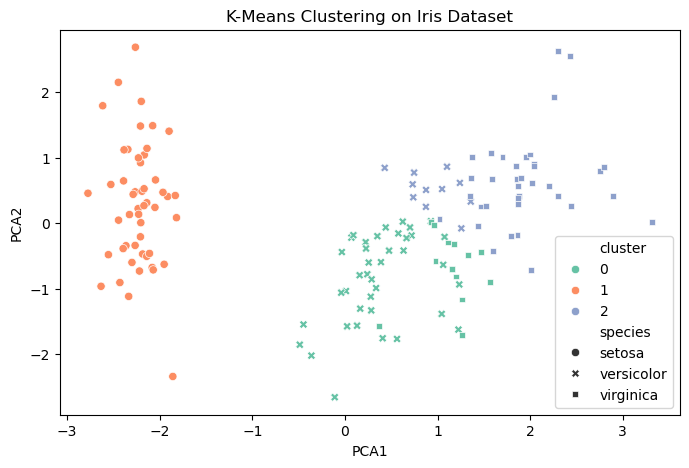

In [9]:
# K-Means on Iris Dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# KMeans is known to have a memory leak on Windows with MKL and the folloing os environment is to supress the warnings
import os
os.environ["OMP_NUM_THREADS"] = "1"           # Fixes MKL memory leak
os.environ["LOKY_MAX_CPU_COUNT"] = "8"        # Optional: silences physical core warning

# Load dataset
iris = sns.load_dataset('iris')
X = iris.drop(columns=['species'])  # Only features

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
iris['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize using PCA (2D projection)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
iris['PCA1'] = X_pca[:, 0]
iris['PCA2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=iris, x='PCA1', y='PCA2', hue='cluster', palette='Set2', style='species')
plt.title("K-Means Clustering on Iris Dataset")
plt.show()

# Part 2: K-Means Clustering on the Diamonds Dataset
Notes:

Use only numerical features for K-Means (it doesn’t handle categorical features directly).

You can one-hot encode cut, color, clarity if needed.

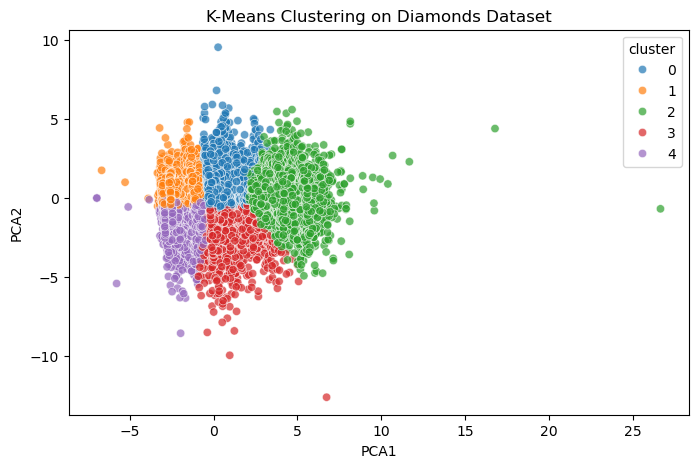

In [10]:
# K-Means on Diamonds Dataset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("C:\\Users\\Somdip.Dey\\Desktop\\Regents_SWE6204\\diamonds.csv")
df.columns = df.columns.str.lower().str.strip()

# Use numeric features only for clustering
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
X = df[numeric_cols]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster', palette='tab10', alpha=0.7)
plt.title("K-Means Clustering on Diamonds Dataset")
plt.show()
